# Corrective RAG (CRAG): Improving Retrieval-Augmented Generation

In the world of **Large Language Models (LLMs)**, **Retrieval-Augmented Generation (RAG)** is a game-changer because it lets AI look up facts.

However, standard RAG has a classic **"garbage in, garbage out"** problem:

> If the retriever picks up irrelevant or low-quality documents, the AI will confidently hallucinate based on bad data.

**Corrective RAG (CRAG)** is a specialized framework designed to fix this by adding a **quality control layer** between the search results and the final answer.

---

## 🧠 How Corrective RAG Works

Think of CRAG as a researcher who doesn’t just grab books off a shelf and start writing, but first checks if the books are actually about the right topic.

---

### 1. The Retrieval Evaluator

Once the system retrieves documents, a lightweight evaluator (often a smaller T5 model or a specialized prompt) assigns a **confidence score** to each document and places them into three buckets:

- **Correct** — highly relevant information  
- **Ambiguous** — somewhat related but unclear  
- **Incorrect** — irrelevant or wrong  

---

### 2. The Action Trigger

Based on those scores, CRAG chooses what to do next:

#### ✅ Knowledge Refinement  
If results are **Correct**, it strips away noise and keeps only vital facts.

#### 🌐 Web Search  
If results are **Incorrect or Ambiguous**, CRAG triggers an external search (Google, Bing, etc.) to fetch better sources.

#### 🧩 Knowledge Composition  
It merges refined internal data with fresh external data into a clean context package.

---

### 3. Final Generation

The LLM receives this **verified, high-quality context** and produces the final answer.

---

## 📊 Standard RAG vs Corrective RAG

| Feature | Standard RAG | Corrective RAG (CRAG) |
|--------|-------------|---------------------|
| **Reliability** | High hallucination risk if retrieval fails | Self-correcting |
| **Data Source** | Only vector database | Can pivot to the web |
| **Precision** | Passes full documents (noise-heavy) | Extracts only relevant snippets |

---

## ✨ The “Corrective” Edge

The real magic of CRAG is its **humility**.

Instead of forcing an answer from poor data, CRAG effectively says:

> *“These documents don’t help. Let me find better ones.”*

And that’s what makes it dramatically more reliable than standard RAG systems.


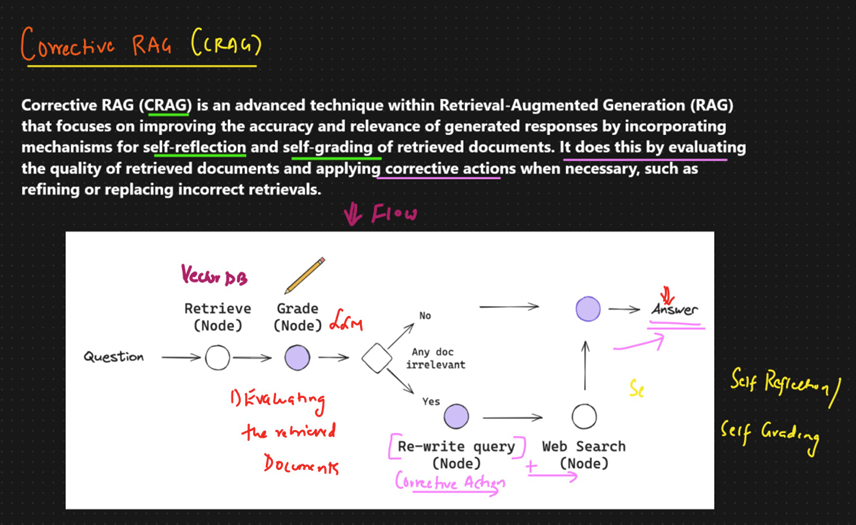

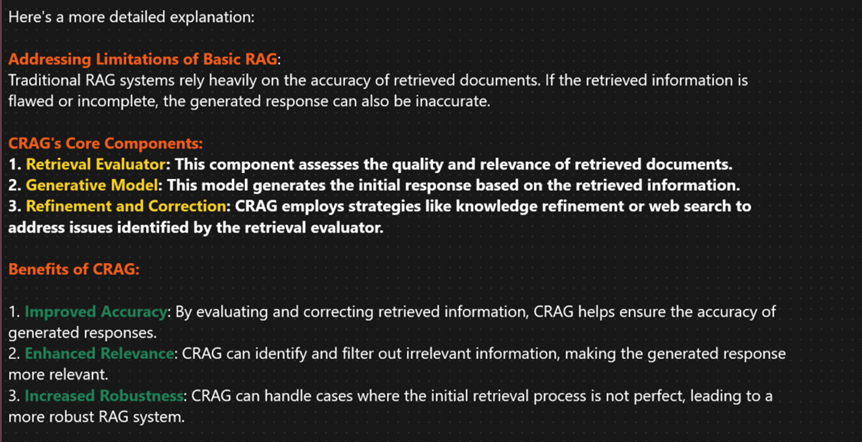

In [36]:
import os
from dotenv import load_dotenv
load_dotenv() ## aloading all the environment variable

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [37]:
### Build Index

from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings

### from langchain_cohere import CohereEmbeddings

# Set embeddings
embd = OpenAIEmbeddings()

# Docs to index
urls = [
    "https://lilianweng.github.io/posts/2023-06-23-agent/",
    "https://lilianweng.github.io/posts/2023-03-15-prompt-engineering/",
    "https://lilianweng.github.io/posts/2023-10-25-adv-attack-llm/",
]

# Load
docs = [WebBaseLoader(url).load() for url in urls]
docs_list = [item for sublist in docs for item in sublist]

# Split
text_splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    chunk_size=500, chunk_overlap=0
)
doc_splits = text_splitter.split_documents(docs_list)

# Add to vectorstore
vectorstore=FAISS.from_documents(
    documents=doc_splits,
    embedding=OpenAIEmbeddings()
)

retriever=vectorstore.as_retriever()

In [38]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI

from pydantic import BaseModel, Field

# Data Model
class GradeDocuments(BaseModel):
    """ Binary score for relevance check on retrived documents """
    binary_score :str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

## Initialize LLM model 
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model_name="gpt-4o", temperature=0)
llm 

structured_llm_grade = llm.with_structured_output(GradeDocuments)

#Prompt 
system = """ You are a grader assessing relevance of a retrieved document to a user question. \n 
    If the document contains keyword(s) or semantic meaning related to the question, grade it as relevant. \n
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question."""
 
grade_prompt = ChatPromptTemplate.from_messages(
    [
        ("system" , system),
        ("human", "Retrieved document: \n\n {document} \n\n User Question: {question}")
    ]
)

## Chain the prompt with the LLM
retrieval_grader = grade_prompt | structured_llm_grade
question ="Agent Memory"
docs = retriever.invoke(question)
doc_txt = docs[1].page_content

print(retrieval_grader.invoke({"question" : question, "document":doc_txt}))

binary_score='yes'


In [39]:
### Generate

# from langchainhub import pull
from langsmith import Client
from langchain_core.output_parsers import StrOutputParser

client = Client()
# Pull public prompt from LangChain Hub (needs author handle)
prompt = client.pull_prompt("rlm/rag-prompt")

llm = ChatOpenAI(model_name="gpt-4o", temperature=0)

# Post Processing

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs) 

#chain
rag_chain = prompt | llm| StrOutputParser()

# Run 
generation = rag_chain.invoke({"context" : docs, "question":question})
print(generation)
 

Agent memory in LLM-powered autonomous agents consists of short-term and long-term memory components. Short-term memory involves in-context learning, utilizing the model's finite context window. Long-term memory allows the agent to retain and recall information over extended periods by leveraging an external vector store and fast retrieval mechanisms.


In [40]:
### Question Re-writer

# LLM
llm = ChatOpenAI(model="gpt-3.5-turbo-0125", temperature=0)

# Prompt
system = """You a question re-writer that converts an input question to a better version that is optimized \n 
     for web search. Look at the input and try to reason about the underlying semantic intent / meaning."""
re_write_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        (
            "human",
            "Here is the initial question: \n\n {question} \n Formulate an improved question.",
        ),
    ]
)

question_rewriter = re_write_prompt | llm | StrOutputParser()
question_rewriter.invoke({"question": question})

'What is the role of memory in artificial intelligence agents?'

In [41]:
### Search

from langchain_tavily import TavilySearch

web_search_tool = TavilySearch(k=3)

In [42]:
from typing import List

from typing_extensions import TypedDict


class GraphState(TypedDict):
    """
    Represents the state of our graph.

    Attributes:
        question: question
        generation: LLM generation
        web_search: whether to add search
        documents: list of documents
    """

    question: str
    generation: str
    web_search: str
    documents: List[str]

In [52]:
from langchain_core.documents import Document

def retrieve(state):
    """
    Retrieve documents

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, documents, that contains retrieved documents
    """
    print("---RETRIEVE---")
    question = state["question"]

    # Retrieval
    documents = retriever.invoke(question)
    return {"documents": documents, "question": question}


def generate(state):
    """
    Generate answer

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): New key added to state, generation, that contains LLM generation
    """
    print("---GENERATE---")
    question = state["question"]
    documents = state.get("documents") or []

    # RAG generation
    generation = rag_chain.invoke({"context": documents, "question": question})
    return {"documents": documents, "question": question, "generation": generation}


def grade_documents(state):
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with only filtered relevant documents
    """

    print("---CHECK DOCUMENT RELEVANCE TO QUESTION---")
    question = state["question"]
    documents = state.get("documents") or []

    # Score each doc
    filtered_docs = []
    web_search = "No"
    for d in documents:
        score = retrieval_grader.invoke(
            {"question": question, "document": d.page_content}
        )
        grade = score.binary_score
        if grade == "yes":
            print("---GRADE: DOCUMENT RELEVANT---")
            filtered_docs.append(d)
        else:
            print("---GRADE: DOCUMENT NOT RELEVANT---")
            web_search = "Yes"
            continue
    return {"documents": filtered_docs, "question": question, "web_search": web_search}


def transform_query(state):
    """
    Transform the query to produce a better question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """

    print("---TRANSFORM QUERY---")
    question = state["question"]
    documents = state.get("documents") or []

    # Re-write question
    better_question = question_rewriter.invoke({"question": question})
    return {"documents": documents, "question": better_question}


def web_search(state):
    """
    Web search based on the re-phrased question.

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates documents key with appended web results
    """

    print("---WEB SEARCH---")
    question = state["question"]
    documents = state.get("documents") or []

    # Web search
    docs = web_search_tool.invoke({"query": question})
    if isinstance(docs, dict):
        docs = docs.get("results", docs.get("documents", []))
    if isinstance(docs, str):
        web_results_text = docs
    else:
        web_results_text = "\n".join(
            d.get("content", str(d)) if isinstance(d, dict) else str(d)
            for d in docs
        )
    if web_results_text.strip():
        web_results = Document(page_content=web_results_text)
        documents.append(web_results)

    return {"documents": documents, "question": question}


### Edges


def decide_to_generate(state):
    """
    Determines whether to generate an answer, or re-generate a question.

    Args:
        state (dict): The current graph state

    Returns:
        str: Binary decision for next node to call
    """

    print("---ASSESS GRADED DOCUMENTS---")
    state["question"]
    web_search = state["web_search"]
    state["documents"]

    if web_search == "Yes":
        # All documents have been filtered check_relevance
        # We will re-generate a new query
        print(
            "---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---"
        )
        return "transform_query"
    else:
        # We have relevant documents, so generate answer
        print("---DECISION: GENERATE---")
        return "generate"

In [53]:
from langgraph.graph import END, StateGraph, START

workflow = StateGraph(GraphState)

# Define the nodes
workflow.add_node("retrieve", retrieve)  # retrieve
workflow.add_node("grade_documents", grade_documents)  # grade documents
workflow.add_node("generate", generate)  # generate
workflow.add_node("transform_query", transform_query)  # transform_query
workflow.add_node("web_search_node", web_search)  # web search

# Build graph
workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "grade_documents")
workflow.add_conditional_edges(
    "grade_documents",
    decide_to_generate,
    {
        "transform_query": "transform_query",
        "generate": "generate",
    },
)
workflow.add_edge("transform_query", "web_search_node")
workflow.add_edge("web_search_node", "generate")
workflow.add_edge("generate", END)

# Compile
app = workflow.compile()

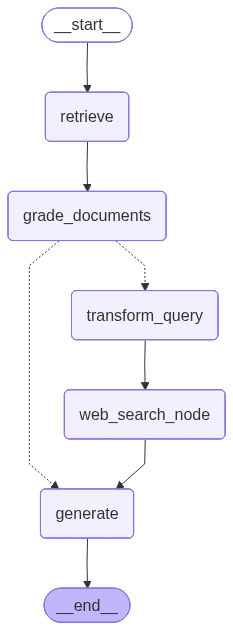

In [49]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [54]:
app.invoke({"question":"What are the types of agent memory?"})

---RETRIEVE---
---CHECK DOCUMENT RELEVANCE TO QUESTION---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---GRADE: DOCUMENT NOT RELEVANT---
---GRADE: DOCUMENT RELEVANT---
---ASSESS GRADED DOCUMENTS---
---DECISION: ALL DOCUMENTS ARE NOT RELEVANT TO QUESTION, TRANSFORM QUERY---
---TRANSFORM QUERY---
---WEB SEARCH---
---GENERATE---


{'question': 'What different types of memory do agents possess?',
 'generation': 'Agents possess different types of memory, including short-term memory, long-term memory, and episodic memory. Short-term memory involves in-context learning within the finite context window of a model. Long-term memory allows agents to retain and recall information over extended periods, often using external storage, while episodic memory stores sequences of past actions to inform future interactions.',
 'web_search': 'Yes',
 'documents': [Document(id='3e2bd8ff-20d2-4cfa-9cd4-0709b826db07', metadata={'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/', 'title': "LLM Powered Autonomous Agents | Lil'Log", 'description': 'Building agents with LLM (large language model) as its core controller is a cool concept. Several proof-of-concepts demos, such as AutoGPT, GPT-Engineer and BabyAGI, serve as inspiring examples. The potentiality of LLM extends beyond generating well-written copies, stories, ess